# 📊 Khám phá Dữ liệu (Exploratory Data Analysis - EDA)
Notebook này giúp nhóm có cái nhìn tổng quan về bộ dữ liệu PlantVillage trước khi bắt tay vào train mô hình. Các biểu đồ ở đây rất hữu ích để đưa vào báo cáo Word (Phần II).

### Lộ trình phân tích dữ liệu (EDA)

**Giai đoạn 1: EDA trên toàn bộ dữ liệu (trước khi chia)**
Thường được dùng để đánh giá chất lượng tổng quan của nguồn dữ liệu:
- Có bao nhiêu class tất cả?
- Kích thước ảnh (chiều cao, chiều rộng) có đồng đều không?
- Phân bố số lượng ảnh của các class (Class Imbalance) tổng quan như thế nào?
- Có ảnh nào bị lỗi không mở được (corrupted) không?

**Giai đoạn 2: EDA và Tính toán thống kê (Bắt buộc chỉ trên Train)**
- **Tính giá trị trung bình (mean) và độ lệch chuẩn (std)** của các pixel để làm chuẩn hóa (Normalization). Bạn BẮT BUỘC phải tính các thông số này chỉ từ tập train, sau đó áp dụng chính con số đó để chuẩn hóa tập val và test.
- **Đánh giá chi tiết sự mất cân bằng dữ liệu** để quyết định xem có cần dùng kỹ thuật Augmentation (Data Augmentation) hay đổi hàm Loss không. Kỹ thuật này cũng chỉ nên dựa vào sự mất cân bằng của tập train để quyết định.

# 1. EDA trên toàn bộ dữ liệu

1. Tải dữ liệu gốc
-> Tổng số lớp (Class): 38

2. Phân tích kích thước và số lượng
-> Tổng số ảnh trên toàn bộ dữ liệu: 54305
-> Số lượng ảnh lỗi (corrupted): 0

3. Thống kê kích thước ảnh (dựa trên tập mẫu):
-> Chiều rộng (Width) - Nhỏ nhất: 256, Lớn nhất: 256, Đa số: 256
-> Chiều cao (Height) - Nhỏ nhất: 256, Lớn nhất: 256, Đa số: 256

4. Biểu đồ phân bố Class Imbalance:


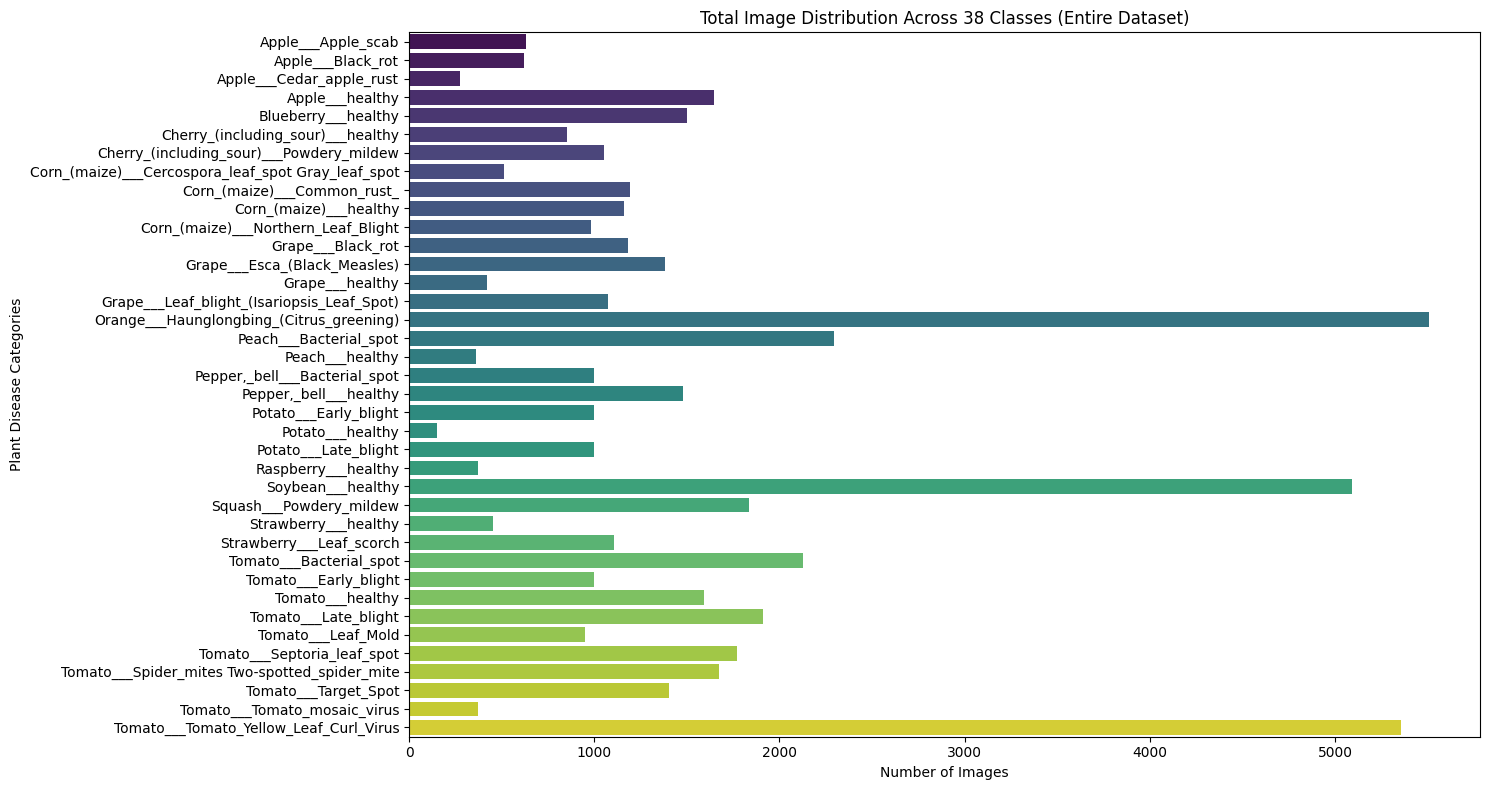

In [11]:
# =========================================================================
# GIAI ĐOẠN 1: EDA TRÊN TOÀN BỘ DỮ LIỆU GỐC (Trước khi chia Train/Val/Test)
# =========================================================================
import kagglehub
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("1. Tải dữ liệu gốc")
# Tận dụng cache của kagglehub, sẽ không tải lại nếu đã tải rồi
dataset_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
source_dir = os.path.join(dataset_path, "plantvillage dataset", "color")
if not os.path.exists(source_dir):
    source_dir = dataset_path

class_names = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
print(f"-> Tổng số lớp (Class): {len(class_names)}")

print("\n2. Phân tích kích thước và số lượng")
class_counts = {}
widths = []
heights = []
corrupted_images = []

for cls in class_names:
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.JPG', '.png', '.jpeg'))]
    class_counts[cls] = len(images)
    
    # Chỉ lấy mẫu 50 ảnh mỗi class để đọc kích thước cho nhanh (tránh lag Jupyter)
    for img_name in images[:50]:
        img_path = os.path.join(cls_path, img_name)
        try:
            img = cv2.imread(img_path)
            if img is None: # Nếu file tồn tại nhưng không thể giải mã thành ảnh (ví dụ: bị hỏng bit, sai định dạng)
                corrupted_images.append(img_path)
            else:
                h, w, _ = img.shape  # Nếu đọc thành công thì mới lấy kích thước
                widths.append(w)
                heights.append(h)
        except Exception:
            corrupted_images.append(img_path)

print(f"-> Tổng số ảnh trên toàn bộ dữ liệu: {sum(class_counts.values())}")
print(f"-> Số lượng ảnh lỗi (corrupted): {len(corrupted_images)}")

print("\n3. Thống kê kích thước ảnh (dựa trên tập mẫu):")
print(f"-> Chiều rộng (Width) - Nhỏ nhất: {min(widths)}, Lớn nhất: {max(widths)}, Đa số: {max(set(widths), key=widths.count)}")
print(f"-> Chiều cao (Height) - Nhỏ nhất: {min(heights)}, Lớn nhất: {max(heights)}, Đa số: {max(set(heights), key=heights.count)}")

print("\n4. Biểu đồ phân bố Class Imbalance:")
plt.figure(figsize=(15, 8))
sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette="viridis")
plt.title("Total Image Distribution Across 38 Classes (Entire Dataset)")
plt.xlabel("Number of Images")
plt.ylabel("Plant Disease Categories")
plt.tight_layout()
plt.show()


## Phát hiện từ biểu đồ Phân phối Lớp

1. **Dữ liệu mất cân bằng rất nghiêm trọng**: Chênh lệch giữa lớp nhiều nhất và lớp ít nhất lên tới vài chục lần. => Nếu cứ thế đem đi train, mô hình nhận diện cực tốt các lớp nhiều ảnh nhưng lại đoán sai các lớp ít ảnh.

2. **Khoảng phân bố chung**: Đa số các lớp (khoảng 30/38 lớp) tập trung ổn định trong khoảng 500 đến 2.500 ảnh. => Lượng dữ liệu vừa đủ để mô hình CNN bắt đầu học được các đặc trưng của lá cây.

3. **3 lớp nhiều ảnh nhất (Cao vượt trội từ 5.000 đến 5.500 ảnh)**:
- `Orange___Haunglongbing_(Citrus_greening)` (Bệnh vàng lá gân xanh trên cam)
- `Soybean___healthy` (Đậu nành khỏe mạnh)
- `Tomato___Tomato_Yellow_Leaf_Curl_Virus` (Cà chua bị xoăn lá do virus)

4. **Các lớp ít ảnh nhất (Thiếu hụt dữ liệu trầm trọng)**:
- `Potato___healthy` (Khoai tây khỏe mạnh) là lớp ít ảnh nhất (thực tế chỉ có khoảng vài chục tấm ảnh).
- Một số lớp khác cũng quá ít ảnh (dưới 500 ảnh): `Apple___Cedar_apple_rust`, `Tomato___Tomato_mosaic_virus`, `Raspberry___healthy`, và `Strawberry___healthy`.

In [2]:
# Sắp xếp danh sách class theo số lượng ảnh từ thấp đến cao
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1])

print("🔴 TOP 3 LỚP ÍT ẢNH NHẤT:")
for cls, count in sorted_classes[:3]:
    print(f"- {cls}: {count} ảnh")

print("\n🟢 TOP 3 LỚP NHIỀU ẢNH NHẤT:")
# Lấy 3 phần tử cuối cùng nhưng đảo ngược lại (để số lớn nhất nằm đầu)
for cls, count in reversed(sorted_classes[-3:]):
    print(f"- {cls}: {count} ảnh")

# Lấy lớp ít nhất và nhiều nhất để tính chênh lệch
min_class, min_count = sorted_classes[0]
max_class, max_count = sorted_classes[-1]

print("\n📊 THỐNG KÊ CHÊNH LỆCH:")
print(f"=> Lớp nhiều ảnh nhất ({max_count} ảnh) đang gấp {max_count / min_count:.1f} lần so với lớp ít ảnh nhất ({min_count} ảnh).")


🔴 TOP 3 LỚP ÍT ẢNH NHẤT:
- Potato___healthy: 152 ảnh
- Apple___Cedar_apple_rust: 275 ảnh
- Peach___healthy: 360 ảnh

🟢 TOP 3 LỚP NHIỀU ẢNH NHẤT:
- Orange___Haunglongbing_(Citrus_greening): 5507 ảnh
- Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 ảnh
- Soybean___healthy: 5090 ảnh

📊 THỐNG KÊ CHÊNH LỆCH:
=> Lớp nhiều ảnh nhất (5507 ảnh) đang gấp 36.2 lần so với lớp ít ảnh nhất (152 ảnh).


## Giải pháp
1. Về Metric đánh giá: dùng thêm F1-Score (Macro) và Confusion Matrix (Ma trận nhầm lẫn) để kiểm soát kỹ xem mô hình có bị đoán sai ở các lớp ít ảnh như Khoai tây hay không.
2. Về Tiền xử lý (Preprocessing): áp dụng Data Augmentation (xoay, lật, tăng giảm độ sáng) để tạo thêm nhiều bản thể dữ liệu + chống học vẹt
3. Về Huấn luyện (Training): cấu hình hàm Loss sử dụng Class Weights (gán trọng số lỗi cao hơn cho các lớp ít ảnh) để ép mô hình phải học kỹ các lớp này.



# 2. EDA trên tập train

In [3]:
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

## 1. Kiểm tra phân phối Dữ liệu
Để biết được dữ liệu có bị mất cân bằng (Imbalanced Data) hay không.

In [4]:
# Đường dẫn đến thư mục data
data_dir = '../data/train'

if not os.path.exists(data_dir):
    print("Lỗi: Đường dẫn ../data/train không tồn tại. Vui lòng chạy file src/data_prep.py trước để tải dữ liệu.")
else:
    class_names = os.listdir(data_dir)
    class_counts = {}
    
    for cls in class_names:
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    
    print(f"Tổng số lớp (Class): {len(class_counts)}")
    print(f"Tổng số ảnh trong tập train: {sum(class_counts.values())}")

Tổng số lớp (Class): 38
Tổng số ảnh trong tập train: 37998


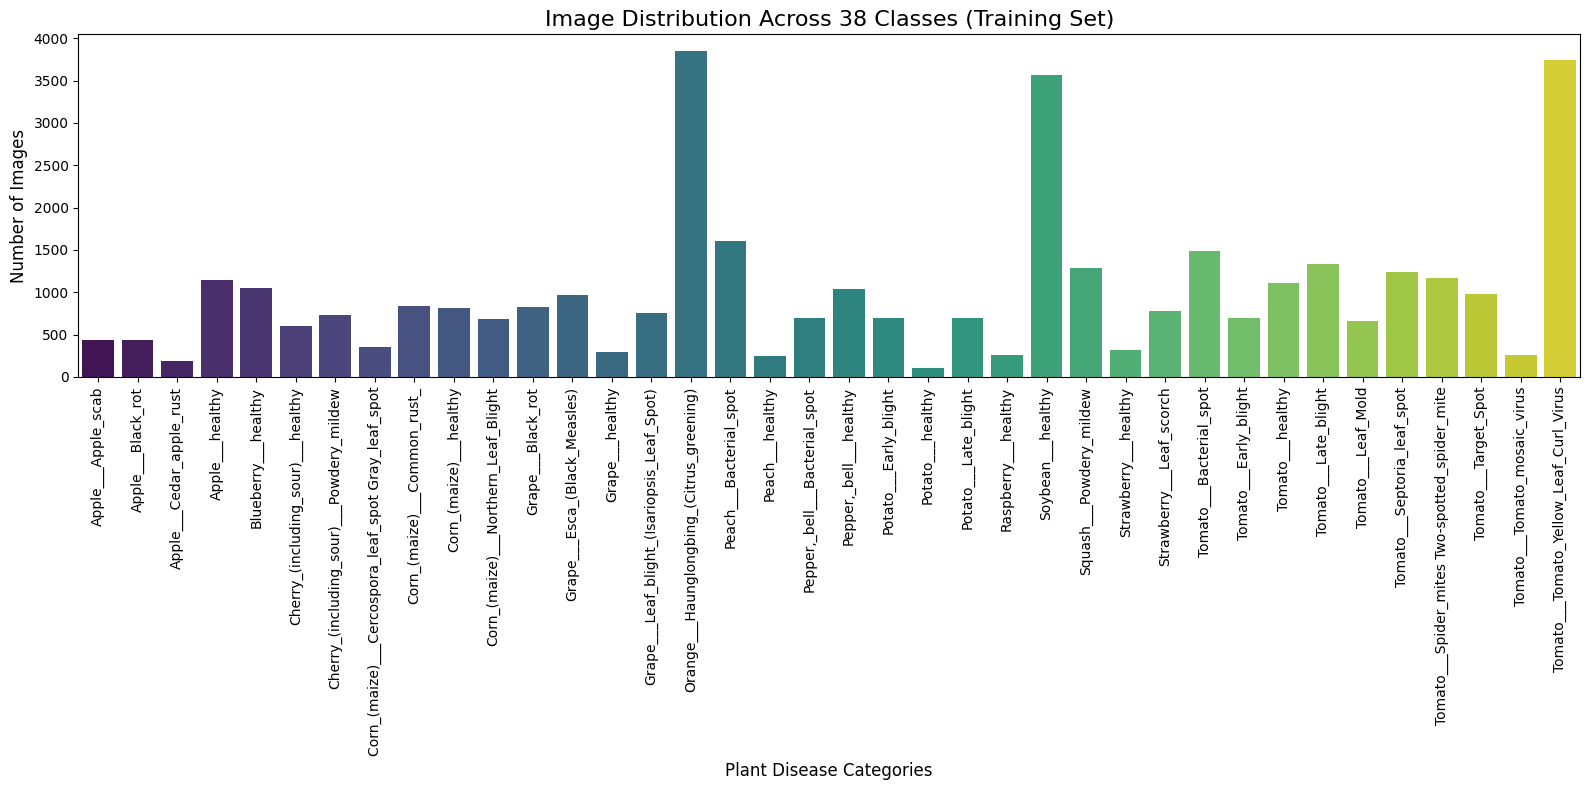

In [5]:
if os.path.exists(data_dir):
    plt.figure(figsize=(16, 8))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
    plt.xticks(rotation=90)
    plt.title('Image Distribution Across 38 Classes (Training Set)', fontsize=16)
    plt.xlabel('Plant Disease Categories', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.tight_layout()
    plt.show()


## 2. Trực quan hóa Ảnh thực tế
Hiển thị ngẫu nhiên các ảnh để quan sát màu sắc và cấu trúc của lá cây bị bệnh.

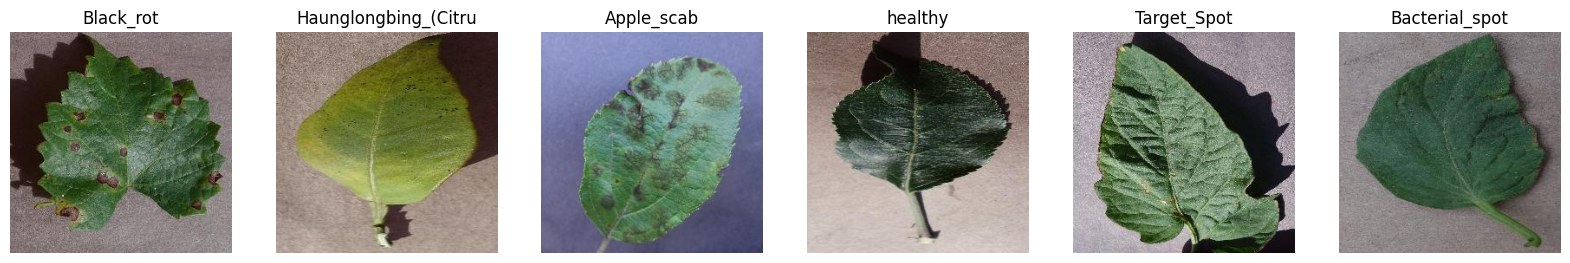

In [6]:
def plot_random_samples(data_dir, num_samples=5):
    plt.figure(figsize=(20, 5))
    classes = np.random.choice(class_names, num_samples, replace=False)
    
    for i, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        img_name = np.random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_name)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        # Cắt tên bệnh cho ngắn gọn
        short_name = cls.split('___')[-1][:20]
        plt.title(short_name, fontsize=12)
        plt.axis('off')
    plt.show()

if os.path.exists(data_dir):
    plot_random_samples(data_dir, 6)

## 3. Kiểm tra kích thước ảnh gốc
Bước này giúp chúng ta biết cần thiết lập tiền xử lý Data Augmentation (trong kịch bản train) là bao nhiêu.

In [7]:
if os.path.exists(data_dir):
    sample_cls = class_names[0]
    sample_img_path = os.path.join(data_dir, sample_cls, os.listdir(os.path.join(data_dir, sample_cls))[0])
    img = cv2.imread(sample_img_path)
    print(f"Kích thước ảnh đầu vào gốc (Width, Height, Channels): {img.shape}")
    print("Lưu ý: Khi đưa vào mô hình, nên resize về (224, 224, 3) để đồng bộ hóa.")

Kích thước ảnh đầu vào gốc (Width, Height, Channels): (256, 256, 3)
Lưu ý: Khi đưa vào mô hình, nên resize về (224, 224, 3) để đồng bộ hóa.


## 4. Tính mean và std của tập train (Z-score Normalization)

In [8]:

import os
import cv2
import numpy as np

train_dir = '../data/train'
class_names = os.listdir(train_dir)

pixel_num = 0 # Biến đếm tổng số lượng pixel
channel_sum = np.zeros(3) # Tổng giá trị pixel theo 3 kênh màu RGB
channel_sum_squared = np.zeros(3) # Tổng bình phương giá trị pixel

print("Đang duyệt qua toàn bộ tập Train để tính toán. Vui lòng đợi...")
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    if not os.path.isdir(cls_path): continue
    
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = cv2.imread(img_path)
        if img is None: continue
        
        # Chuyển từ BGR (OpenCV) sang hệ màu RGB (Chuẩn Deep Learning)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Đưa pixel về [0, 1] trước khi tính toán để số khỏi bị tràn
        img = img.astype(np.float32) / 255.0
        
        # Tính toán cộng dồn
        pixel_num += (img.shape[0] * img.shape[1])
        channel_sum += np.sum(img, axis=(0, 1))
        channel_sum_squared += np.sum(np.square(img), axis=(0, 1))

# Công thức tính Mean (Kỳ vọng)
rgb_mean = channel_sum / pixel_num

# Công thức tính Std (Căn bậc hai của Phương sai)
# Phương sai = E[X^2] - (E[X])^2
rgb_std = np.sqrt((channel_sum_squared / pixel_num) - np.square(rgb_mean))

print("\n✅ HOÀN TẤT!")
print(f"-> Giá trị Mean (Red, Green, Blue) của tập Train: {rgb_mean}")
print(f"-> Giá trị Std  (Red, Green, Blue) của tập Train: {rgb_std}")


Đang duyệt qua toàn bộ tập Train để tính toán. Vui lòng đợi...


KeyboardInterrupt: 

**1. Phân tích giá trị trung bình (Mean - Thể hiện tông màu chủ đạo):**
- Xanh lá (Green) = 0.489 (Cao nhất)
- Đỏ (Red) = 0.466 (Đứng thứ hai)
- Xanh dương (Blue) = 0.410 (Thấp nhất)

👉 Nhận xét: Mức phân bố này phản ánh chính xác đặc trưng sinh học của bộ dữ liệu thực vật (PlantVillage). Màu Xanh lá chiếm ưu thế tuyệt đối do màu sắc tự nhiên của chất diệp lục trên lá cây. Màu Đỏ bám sát ở vị trí thứ hai cho thấy sự xuất hiện dày đặc của các mảng màu vàng/nâu/đỏ - đây chính là dấu hiệu của các vết bệnh lý (cháy lá, đốm lá, nấm rỉ sắt) trên bề mặt thực vật. Màu xanh dương thấp nhất vì ít liên quan đến đặc tính của lá cây.

**2. Phân tích độ lệch chuẩn (Std - Thể hiện độ biến thiên/độ tương phản):**

- Xanh dương (Blue) = 0.217 (Biến thiên mạnh nhất)
- Đỏ (Red) = 0.199
- Xanh lá (Green) = 0.174 (Ổn định nhất)

👉 Nhận xét: Chỉ số Std của kênh Xanh lá thấp nhất cho thấy sắc xanh trên các bức ảnh rất đồng đều và ổn định (gần như lá nào cũng có màu xanh tương tự nhau). Ngược lại, kênh Đỏ và Xanh dương có độ biến thiên cao chứng tỏ độ nghiêm trọng của vết bệnh (màu nâu/đỏ) và điều kiện ánh sáng nền, bóng râm (màu xanh dương) thay đổi rất mạnh giữa các bức ảnh khác nhau.

**3. Giải pháp chuẩn hóa Z-Score:**

Dựa trên các chỉ số thu thập được: Mean = [0.466, 0.489, 0.410] và Std = [0.199, 0.174, 0.217], nhóm sẽ áp dụng phương pháp chuẩn hóa Z-Score thay vì chỉ chia tỷ lệ 1/255 thông thường. Phép biến đổi (Pixel - Mean) / Std sẽ nén toàn bộ không gian màu sắc về dạng phân phối chuẩn xoay quanh mức 0. Điều này giải quyết bài toán lệch pha khởi tạo trọng số, giúp các mô hình tự thiết kế (Simple CNN, Complex CNN) giảm thiểu bão hòa Gradient và hội tụ tốc độ cao.